# Knowledge graph generation

In [12]:
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap
from dotenv import load_dotenv
import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

from rag.utils.utils import load_json_data

warnings.filterwarnings("ignore")

TEMP_ENTITIES_FILE = "temp_entities.json"
TEMP_RELATIONSHIPS_FILE = "temp_relationships.json"

ENV_PATH = os.path.join(os.path.dirname(os.getcwd()), ".env")
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "data/")
NUM_RETRIES = 3

load_dotenv(dotenv_path=ENV_PATH)

True

Load web scraped data from json files to langchain documents.

In [13]:
data = load_json_data(DATA_PATH)
print("Number of documents: {}".format(len(data)))

Number of documents: 3935


## Data extraction

In [14]:
from rag.models.google_genai_models import GraphExtractorModel

graph_extractor = GraphExtractorModel()
print(graph_extractor.prompt_template)


Given a text document related to AGH University of Science and Technology and university life, extract domain-specific entities and their relationships that would be valuable for a knowledge graph about the university ecosystem.

Objective
Extract only entities that:
- Are specific to AGH University or academic environments
- Provide information not generally known to large language models
- Represent meaningful nodes in a university knowledge graph
- Capture the structural organization and relationships within the institution

Extraction Guidelines
Entity Extraction
For each relevant entity, provide:

entity_name: Name of the entity, properly capitalized
entity_type: One or more applicable types from the entity type list
entity_description: Concise description focusing on its role in the university structure

Important: Do NOT extract generic entities that exist in general knowledge (e.g., "Europe," "Mathematics," "Internet"). Only extract specific instances, programs, systems, or el

/home/michal/Documents/projects/ChatAGH/rag/models/google_genai_models.py:12: LangChainPendingDeprecationWarning: langchain.indexes.prompts will be removed in the future.If you're relying on these prompts, please open an issue on GitHub to explain your use case.
  from rag.models.prompts import (


In [15]:
try:
    entities = pd.read_json(TEMP_ENTITIES_FILE)
    print("Temporary entities file found")
except FileNotFoundError:
    entities = pd.DataFrame(columns=["entity_name", "entity_type", "entity_description", "num_doc"])
    print("Created temporary entities file")

try:
    relationships = pd.read_json(TEMP_RELATIONSHIPS_FILE)
    print("Temporary relationships file found")
except FileNotFoundError:
    relationships = pd.DataFrame(columns=["source_entity", "target_entity", "relationship_description", "num_doc"])
    print("Created temporary relationships file")

Temporary entities file found
Temporary relationships file found


In [16]:
start_doc = min(max(list(relationships["num_doc"]) + [0]), max(list(entities["num_doc"]) + [0]))
msg = f"{start_doc} documents already processed, resuming ... " if start_doc > 0 else "Processing started"
print(msg)

for num_doc in range(start_doc, len(data)):
    file = data[num_doc]
    processed_docs = len(relationships["num_doc"].unique())
    print(f"Processing file: {num_doc + 1} / {len(data)}, successfully processed files: {processed_docs}")

    res = graph_extractor.generate(file.page_content)

    res_entities_df = pd.DataFrame(res["entities"])
    res_entities_df["num_doc"] = num_doc

    res_relationships_df = pd.DataFrame(res["relationships"])
    res_relationships_df["num_doc"] = num_doc

    entities = pd.concat([entities, res_entities_df], ignore_index=True)
    relationships = pd.concat([relationships, res_relationships_df], ignore_index=True)

    entities.to_json(TEMP_ENTITIES_FILE)
    relationships.to_json(TEMP_RELATIONSHIPS_FILE)


3935 documents already processed, resuming ... 


In [17]:
print(f"{len(entities)} entities records extracted")
print(f"{len(relationships)} relationships records extracted")

12338 entities records extracted
13327 relationships records extracted


## Data processing

### Entities

Group all entities records by entity name

In [18]:
entities = entities.groupby(entities.index).agg({
    'entity_type': lambda x: sum(x, []),
    'entity_description': list,
})
print(f"Number of entities: {len(entities)}")

Number of entities: 12338


Get unique labels

In [19]:
entities["entity_type"] = entities["entity_type"].apply(lambda x: list(set(x)))

Get entity importance as number of entity records

In [20]:
entities["importance"] = entities["entity_description"].apply(lambda x: len(x))
entities.sort_values("importance", ascending=False, inplace=True)
entities.head(5)

,entity_type,entity_description,importance
#JESTEMZAGH,"[PROGRAM, PROJECT, EVENT, RESOURCE]","[[A promotional action or campaign at AGH, as ...",1
Przedstawiciele studentów,[PERSON],[[Student representatives in the Faculty Counc...,1
Postępowania awansowe,[PROCEDURE],[[Advancement procedures]],1
Pozostali nauczyciele akademiccy,[PERSON],[[Other academic teachers who are part of the ...,1
Pracownia Detektorów,[LABORATORY],[[Laboratory of Detectors at AGH]],1


Entities descriptions summarization

In [154]:
from rag.models.google_genai_models import BaseGoogleModel

ENTITY_SUMMARIZATION_PROMPT = f"""
You will be a given list of texts and labels describing some entity related with AGH university.

Your task is to generate description for this entity. Description should be comprehensive and contain all information from provided texts and labels.

ENTITY:
{{QUERY}}

DESCRIPTION:
"""

class EntitySummarizationModel(BaseGoogleModel):
    def __init__(self, **kwargs):
        super().__init__(prompt_template=ENTITY_SUMMARIZATION_PROMPT, **kwargs)

In [155]:
entity_summarization_model = EntitySummarizationModel()

for i, row in enumerate(entities.iterrows()):
    if row[1]["description"] is None:
        index = row[0]
        if len(row[1]["entity_description"]) > 1:
            context = "{}   {}".format(
                set(row[1]["entity_description"]),
                set(row[1]["entity_type"])
            )
            result = entity_summarization_model.generate(query=context)
        else:
            result = row[1]["entity_description"][0]

        print("\n\n\n")
        print(index)
        print(result)
        entities.at[index, "description"] = result

        processed = sum(1 for d in entities["description"] if d is not None)
        missing = len(entities) - processed
        print(f"Processed {processed} entities - {missing} entities left")

        entities.to_json(TEMP_ENTITIES_FILE)





WEAIIE
Wydział Elektrotechniki, Automatyki, Informatyki i Elektroniki (Faculty of Electrical Engineering, Automatics, Computer Science and Electronics)
Processed 6966 entities - 5372 entities left




TWORZENIE PRZESTRZENI WIRTUALNYCH I GIER
Course in Virtual Space and Games.
Processed 6967 entities - 5371 entities left




TWÓRZYWA I TECHNOLOGIE MOTORYZACYJNE (TiTM), I ST.
Bachelor's degree program in Automotive Materials and Technologies at AGH UST, participating in the KOMPAS AGH project
Processed 6968 entities - 5370 entities left




TWÓRZYWA I TECHNOLOGIE MOTORYZACYJNE (TiTM), II ST.
Master's degree program in Automotive Materials and Technologies at AGH UST, participating in the KOMPAS AGH project
Processed 6969 entities - 5369 entities left




TYFLOMAPA AGH
Map for visually impaired on AGH premises
Processed 6970 entities - 5368 entities left




TYMOTEUSZ TURLEJ
Dr ing. Tymoteusz Turlej from Wydziat Inzynierii Mechanicznej i Robotyki
Processed 6971 entities - 5367 entitie

### Relationships

Group relationships by source entity - target entity pairs

In [156]:
def create_entity_pair(row):
    entities = sorted([row['source_entity'], row['target_entity']])
    return tuple(entities)

relationships['entity_pair'] = relationships.apply(create_entity_pair, axis=1)

result = relationships.groupby('entity_pair').agg({
    'relationship_description': lambda x: list(x),
    'source_entity': 'first',
    'target_entity': 'first'
}).reset_index()

result = result.drop(columns=['entity_pair'])

relationships = result[['source_entity', 'target_entity', 'relationship_description']]
relationships["description"] = [None for _ in range(len(relationships))]

Get relationships importance as number of records

In [157]:
relationships["importance"] = relationships["relationship_description"].apply(lambda x: len(x))
relationships.sort_values(by="importance", ascending=False, inplace=True)
relationships.head(10)

,source_entity,target_entity,relationship_description,description,importance
0,#JESTEMZAGH COTTON BAG,#JESTEMZAGH,[[The #jestemzAGH cotton bag promotes the #jes...,None,1
9162,LABORATORIUM BADAŃ GEOTECHNICZNYCH I GEOMECHAN...,KATEDRA HYDROGEOLOGII I GEOLOGII INŻYNIERSKIEJ,[[Laboratorium Badań Geotechnicznych i Geomech...,None,1
8878,Jerzy Lis,Krakowskie Centrum Innowacyjnych Technologii I...,[[Jerzy Lis is a przewodniczącym rady nadzorcz...,None,1
8879,Jerzy Lis,Krzyż Kawalerski Orderu Odrodzenia Polski,[[Jerzy Lis was awarded the Krzyż Kawalerski O...,None,1
8880,Jerzy Lis,Medal Komisji Edukacji Narodowej,[[Jerzy Lis was awarded the Medal Komisji Eduk...,None,1
8881,Jerzy Lis,Polskie Towarzystwo Materiałoznawcze (PTM),[[Jerzy Lis served as president of the Polish ...,None,1
8882,Prodziekan ds. Dydaktycznych,Jerzy Lis,[[Jerzy Lis served as the Vice-Dean for Didact...,None,1
8883,Jerzy Lis,Prorektor ds. Współpracy,[[Jerzy Lis held the position of Vice-Rector f...,None,1
8884,Jerzy Lis,Prorektor ds. Współpracy i Rozwoju,[[Jerzy Lis held the position of Vice-Rector f...,None,1
8885,Jerzy Lis,Rada ds. Planu dla Pracy i Rozwoju,[[Jerzy Lis is a member of Rada ds. Planu dla ...,None,1


Relationships descriptions summarization

In [3]:
from rag.models.google_genai_models import BaseGoogleModel

RELATIONSHIP_SUMMARIZATION_PROMPT = f"""
You will be a given a lists of texts about relationships between some entities related with AGH university.

Your task is to generate description for this relationship. Description should be comprehensive and contain all information from provided in texts.

RELATIONSHIP:
{{QUERY}}

DESCRIPTION:
"""

class RelationshipSummarizationModel(BaseGoogleModel):
    def __init__(self, **kwargs):
        super().__init__(prompt_template=RELATIONSHIP_SUMMARIZATION_PROMPT, **kwargs)

/Users/wnowogorski/PycharmProjects/CHAT_AGH/rag/models/google_genai_models.py:11: LangChainPendingDeprecationWarning: langchain.indexes.prompts will be removed in the future.If you're relying on these prompts, please open an issue on GitHub to explain your use case.
  from rag.models.prompts import (


In [7]:
relationship_summarization_model = RelationshipSummarizationModel()

for i, row in enumerate(relationships.iterrows()):
    if row[1]["description"] is None:
        index = row[0]
        if len(row[1]["relationship_description"]) > 1:
            context = "Source entity: {}\n  Target entity: {}\n  Description: {}".format(
                set(row[1]["source_entity"]),
                set(row[1]["target_entity"]),
                set(row[1]["relationship_description"]),

            )
            result = relationship_summarization_model.generate(query=context)
        else:
            result = row[1]["relationship_description"][0]

        print("\n\n\n")
        print(f"{row[1]['source_entity']} - {row[1]['target_entity']}")
        print(result)
        relationships.at[index, "description"] = result

        processed = sum(1 for d in relationships["description"] if d is not None)
        missing = len(relationships) - processed
        print(f"Processed {processed} entities - {missing} entities left")

        relationships.to_json(TEMP_RELATIONSHIPS_FILE)





URSS AGH - KOMISJA KONKURSOWA GRANT REKTORA
The representatives of URSS AGH (Student Research Groups Council at AGH) participate in the Grant Rektora competition committee (Komisja Konkursowa Grant Rektora) that evaluates grant applications.

Processed 1132 entities - 12195 entities left




E-REKRUTACJA - ELS
The E-Rekrutacja system (denoted by the set {'C', 'E', 'K', 'T', 'J', '-', 'U', 'A', 'R'}) is used to facilitate payments for ELS (Elektroniczna Legitymacja Studencka - electronic student ID) {'S', 'E', 'L'}. Specifically, candidates use the E-Rekrutacja system to pay the required fees for their ELS.

Processed 1133 entities - 12194 entities left




MUZEUM HISTORII AGH - JEAN PHILIBERT
The Museum of History at AGH holds biographical materials and materials related to Jean Philibert's honorary doctorate.

Processed 1134 entities - 12193 entities left




OPEN AGH - E-ZASOBY
The OPEN AGH initiative provides access to E-ZASOBY (also referred to as E-zasoby).

Processed 1135 ent

Filter out unwanted columns

In [8]:
relationships.drop(columns=["relationship_description", "num_doc"], inplace=True)
entities.drop(columns=["entity_description", "num_doc"], inplace=True)

Save processed data

In [10]:
entities.head(5)

,entity_type,importance,description
DOKTOR HONORIS CAUSA AGH,"[DEGREE, ACHIEVEMENT]",198,The honorary doctorate awarded by AGH Universi...
HISTORIA AGH,"[ORGANIZATION, DEPARTMENT, RESOURCE, PROJECT, ...",166,"The AGH history project, department, resource,..."
SENAT AGH,"[ORGANIZATION, COMMITTEE]",144,The Senate of AGH University of Science and Te...
AKADEMIA GÓRNICZO-HUTNICZA IM. STANISŁAWA STASZICA W KRAKOWIE,"[ORGANIZATION, FACULTY, UNIVERSITY]",109,"AGH University of Science and Technology, loca..."
AGH,"[ORGANIZATION, FACULTY]",100,"AGH University of Science and Technology, also..."


In [11]:
relationships.head(5)

,source_entity,target_entity,importance,description
5610,SENAT AGH,DOKTOR HONORIS CAUSA AGH,48,The Senate (or Senat) of AGH University is the...
287,BAZA DANYCH O AUTORACH I PUBLIKACJACH AGH,AGH,35,"The ""Baza Danych o Autorach i Publikacjach"" (D..."
544,POCZTA AGH,AGH,23,Poczta AGH is the official email system provid...
2760,BIBLIOTEKA GŁÓWNA AGH,ALMA,22,The Biblioteka Główna AGH (AGH Main Library) i...
533,OPEN AGH – OTWARTE ZASOBY EDUKACYJNE,AGH,21,"AGH University provides and maintains the ""Ope..."


In [12]:
entities.to_json("processed_entities.json")
relationships.to_json("processed_relationships.json")

## Data analysis

Entities descriptions

In [69]:
entities["description"].apply(lambda x: len(x)).describe()

count    12338.000000
mean       155.764954
std        129.293808
min          5.000000
25%         74.000000
50%        116.000000
75%        199.000000
max       2064.000000
Name: description, dtype: float64

In [76]:
entities["description_length"] = entities["description"].apply(lambda x : len(x))
sampled_entities = entities.sort_values(by=["description_length"], ascending=False)[:100].sample(5)
for row in sampled_entities.iterrows():
    print("\n")
    print(row[0])
    print(row[1]["description"])



PROREKTOR DS. STUDENCKICH
The Vice-Rector for Student Affairs is a key administrative position at AGH University of Science and Technology (AGH UST) responsible for all student-related matters. This includes overseeing student affairs, policies, and decisions, as well as managing and allocating funds such as the Grant Rektora program and FNKS funding. The Vice-Rector's office handles communications, organizes the Grant Rektora competition, and oversees student organizations. The Vice-Rector also approves applications for student travel abroad, handles appeals regarding Zapomoga decisions, and serves as the supervisory body for accessibility complaints. The current Vice-Rector for Student Affairs is prof. dr hab. Rafał Dańko. The Vice-Rector is also a member of the Jury responsible for managing scholarship funds.



KATEDRA STUDIÓW NAD KULTURĄ I BADAŃ ERY CYFROWEJ
The Department of Studies on Culture and Research of the Digital Age (also referred to as the Department of Cultural Studi

Most important entities

In [77]:
entities.head(20)[["importance"]]

,importance
AGH,100
AGH UST,13
AKADEMIA GÓRNICZO-HUTNICZA IM. STANISŁAWA STASZICA W KRAKOWIE,109
SKOS AGH,21
HISTORIA AGH,166
AKADEMIA GÓRNICZO-HUTNICZA,62
MIASTECZKO STUDENCKIE AGH,46
AGH UNIVERSITY,24
DOKTOR HONORIS CAUSA AGH,198
BIBLIOTEKA GŁÓWNA AGH,73


Importance distribution

In [51]:
entities["importance"].describe()

count    12338.000000
mean         1.817231
std          4.297659
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        198.000000
Name: importance, dtype: float64

Entities with most relationships

In [48]:
def get_num_relationships(entity_name):
    source_entity_count = len(relationships[relationships["source_entity"] == entity_name])
    target_entity_count = len(relationships[relationships["target_entity"] == entity_name])
    return source_entity_count + target_entity_count

entities["num_relationships"] = entities.index.to_series().apply(get_num_relationships)
entities.sort_values(by="num_relationships", ascending=False, inplace=True)
entities.head(20)[["num_relationships"]]

,num_relationships
AGH,531
AGH UST,235
AKADEMIA GÓRNICZO-HUTNICZA IM. STANISŁAWA STASZICA W KRAKOWIE,207
SKOS AGH,175
HISTORIA AGH,172
AKADEMIA GÓRNICZO-HUTNICZA,158
MIASTECZKO STUDENCKIE AGH,158
AGH UNIVERSITY,145
DOKTOR HONORIS CAUSA AGH,128
BIBLIOTEKA GŁÓWNA AGH,122


Number of relationships per entity distribution

In [49]:
entities["num_relationships"].describe()

count    12338.000000
mean         2.134706
std          8.430627
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        531.000000
Name: num_relationships, dtype: float64

Most important relationships

In [54]:
relationships[["source_entity", "target_entity", "importance"]].head(20)

,source_entity,target_entity,importance
5610,SENAT AGH,DOKTOR HONORIS CAUSA AGH,48
287,BAZA DANYCH O AUTORACH I PUBLIKACJACH AGH,AGH,35
544,POCZTA AGH,AGH,23
2760,BIBLIOTEKA GŁÓWNA AGH,ALMA,22
533,OPEN AGH – OTWARTE ZASOBY EDUKACYJNE,AGH,21
292,BIULETYN AGH,AGH,17
4430,CELIID AGH,WEBINAROTEKA,16
619,SKLEP INTERNETOWY AGH,AGH,15
1115,MAIN LIBRARY,AGH UNIVERSITY,14
1039,AGH UNIVERSITY STUDENT CAMPUS,AGH UNIVERSITY,14


Sample relationships descriptions

In [81]:
relationships["description_length"] = relationships["description"].apply(lambda x : len(x))
sampled_relationships = relationships.sort_values(by=["description_length"], ascending=False)[:100].sample(5)
for row in sampled_relationships.iterrows():
    print("\n")
    print("Source entity: ", row[1]["source_entity"])
    print("Target entity: ", row[1]["target_entity"])
    print(row[1]["description"])



Source entity:  SYSTEM INFORMACYJNY (SKOS)
Target entity:  CELIID AGH
Administrative staff at AGH register for CELIID (Centrum Edukacji Laboratoryjnej i Innowacyjnego Dydaktyki) trainings using their System Informacyjny email address. It is imperative that administrative workers use the same email address for registration on the training platform as they do within SKOS (System Kadrowo-Organizacyjny Szkoły Wyższej) to ensure access to CELIID trainings.



Source entity:  ZAKŁAD GEOLOGII OGÓLNEJ I MATEMATYCZNEJ
Target entity:  WYDZIAŁ GEOLOGII, GEOFIZYKI I OCHRONY ŚRODOWISKA
The Department of General and Mathematical Geology (containing the letters ' ', 'Ó', 'M', 'E', 'L', 'K', 'Y', 'C', 'J', 'T', 'G', 'O', 'A', 'N', 'Ł', 'I', 'Z', 'D') is a department within, and therefore a part of, the Faculty of Geology, Geophysics and Environmental Protection (containing the letters 'Y', 'E', 'A', 'N', 'D', 'Ś', 'L', 'S', 'W', 'Ł', 'R', 'H', 'C', 'K', 'G', 'O', 'F', ' ', ',', 'I', 'Z').



Source 

#### Graph visualization for 50 more important entities

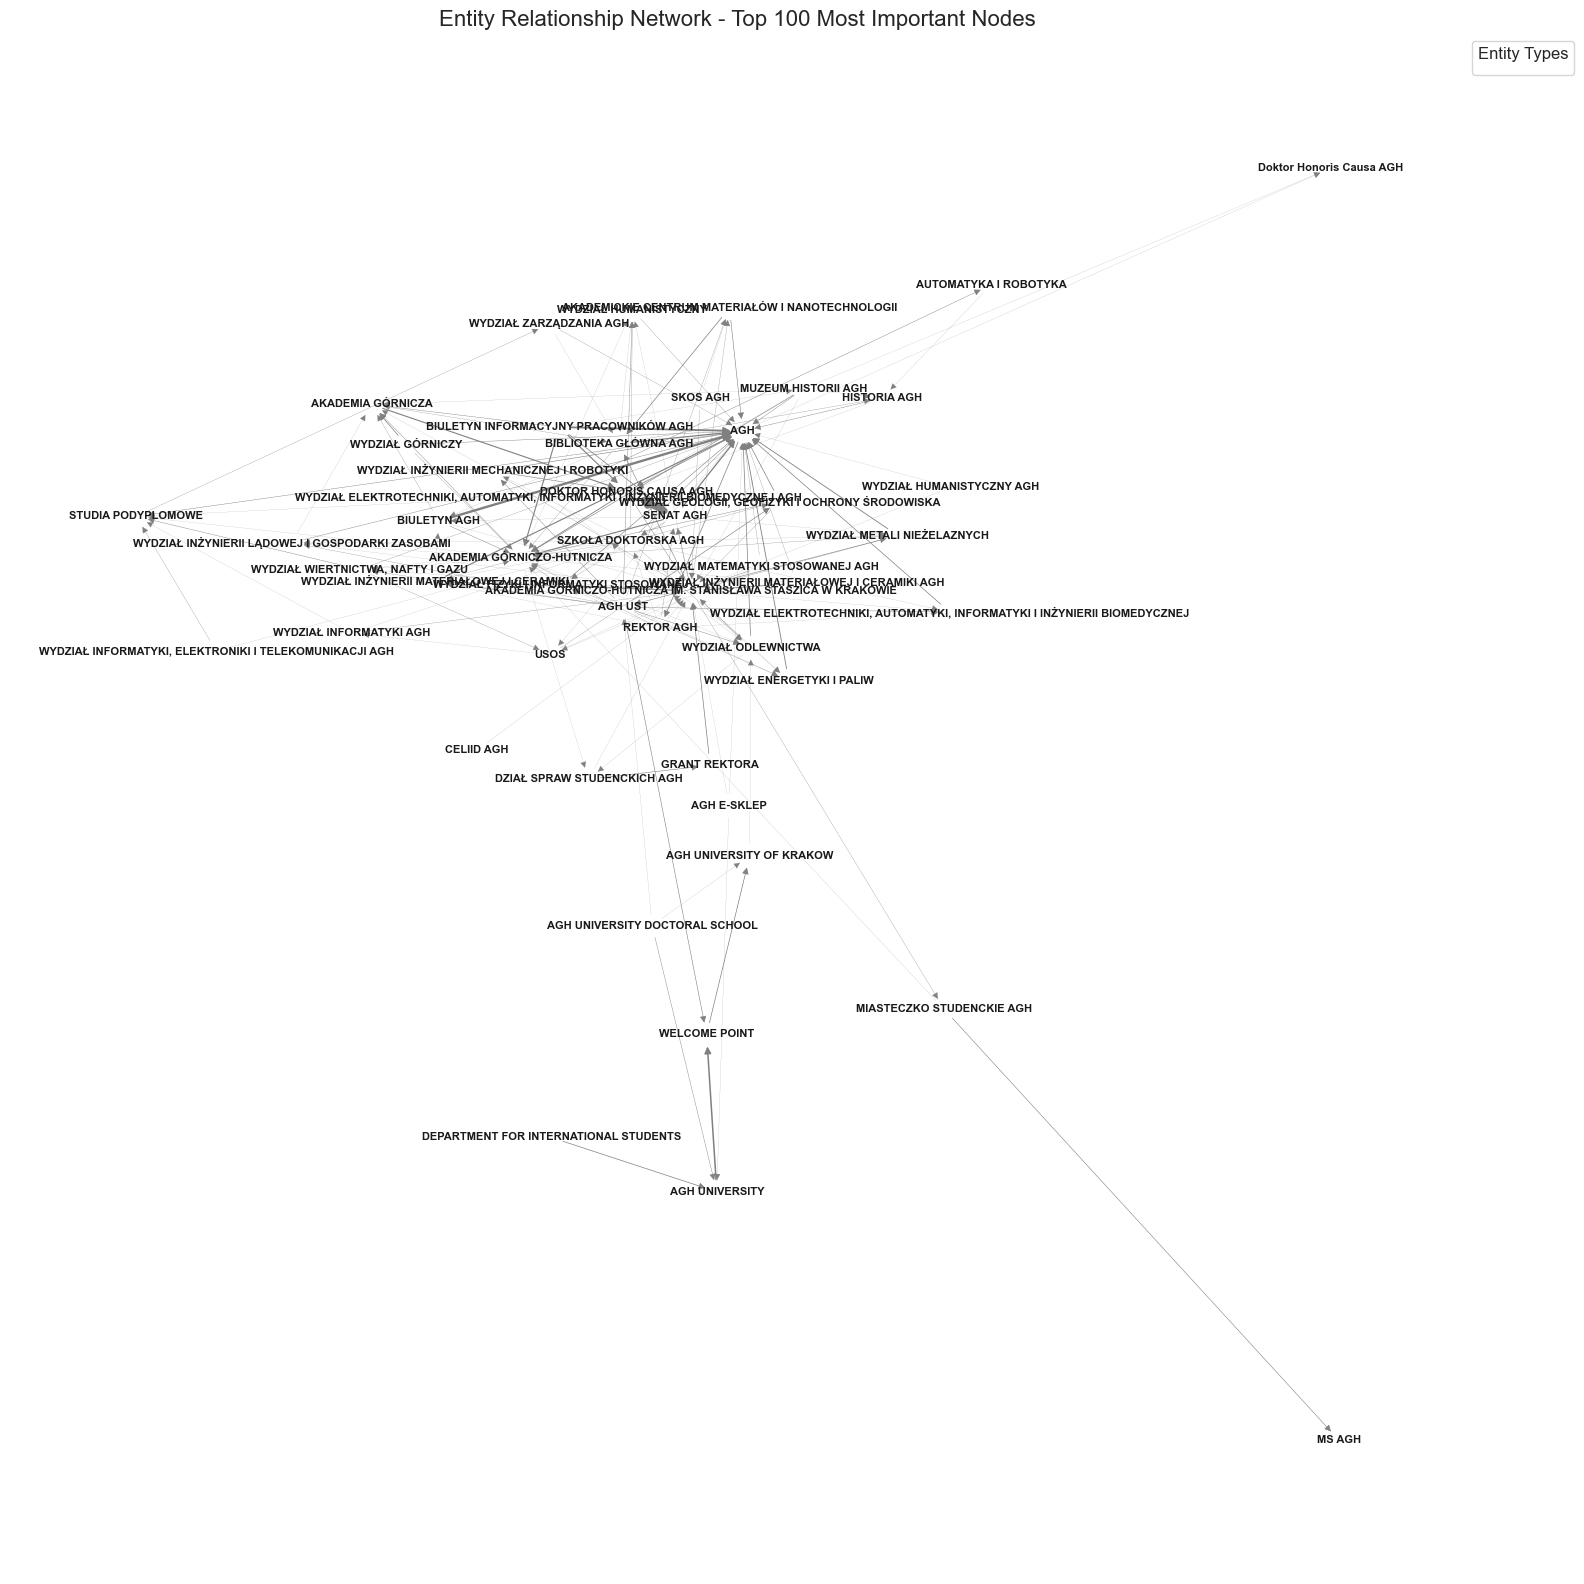

In [82]:
G = nx.from_pandas_edgelist(
    relationships, 'source_entity', 'target_entity',
    edge_attr=['importance', 'description'], create_using=nx.DiGraph()
)

for node in G.nodes():
    if node in entities.index:
        for col in entities.columns:
            G.nodes[node][col] = entities.loc[node, col]

node_importance = {node: G.degree(node) * G.nodes[node].get('importance', 1)
                  for node in G.nodes()}

top_nodes = sorted(node_importance.items(), key=lambda x: x[1], reverse=True)[:50]
top_node_names = [n[0] for n in top_nodes]

subG = G.subgraph(top_node_names)

plt.figure(figsize=(16, 16))
pos = nx.spring_layout(subG, k=0.2, iterations=50, seed=42)

entity_types = list(set([str(x) for x in nx.get_node_attributes(subG, 'entity_type').values()]))
colors = get_cmap('tab20', len(entity_types))

for i, entity_type in enumerate(entity_types):
    nodes_of_type = [n for n in subG.nodes() if subG.nodes[n].get('entity_type') == entity_type]
    nx.draw_networkx_nodes(
        subG, pos, nodelist=nodes_of_type,
        node_size=[subG.nodes[n].get('importance', 1) * 50 for n in nodes_of_type],
        node_color=[colors(i)] * len(nodes_of_type),
        alpha=0.8, label=entity_type
    )

edge_importance = [subG.edges[e].get('importance', 1)/10 for e in subG.edges()]
nx.draw_networkx_edges(subG, pos, width=edge_importance, alpha=1,
                      edge_color='gray', arrows=True, arrowsize=10)

importance_threshold = np.percentile([v for k,v in node_importance.items()], 95)
node_labels = {n: n for n in subG.nodes() if node_importance[n] > importance_threshold}
nx.draw_networkx_labels(subG, pos, labels=node_labels, font_size=8, font_weight='bold')

plt.title("Entity Relationship Network - Top 100 Most Important Nodes", fontsize=16)
plt.legend(title="Entity Types", fontsize=10, loc="upper left", bbox_to_anchor=(1, 1))
plt.axis('off')
plt.tight_layout()
plt.savefig("entity_network.png", dpi=300, bbox_inches='tight')
plt.show()

## Load to Neo4j database